In [1]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_excel("loan_details.xlsx")
data.head()

,customer_id,loan_type,loan_amount,loan_term,interest_rate,loan_purpose,loan_to_value_ratio,origination_channel,loan_officer_id,marketing_campaign
0,10000,Personal,"$17,700",36,12.50,Debt Consolidation,0.000,Direct Mail,1045,W
1,10001,mortgage,"$114,000",180,6.83,Refinance,0.774,Branch,1011,B
2,10002,Personal Loan,"9,300",36,13.99,Major Purchase,0.000,Online,1084,K
3,10003,PERSONAL,$8700,48,13.26,Medical,0.000,Online,1048,A
4,10004,Personal,"$7,200",24,10.77,Debt Consolidation,0.000,Branch,1055,S


In [5]:
data.shape

(89999, 10)


=== BASIC STATISTICS ===
         customer_id loan_type    loan_amount     loan_term  interest_rate  \
count   89999.000000     89999   89999.000000  89999.000000   89999.000000   
unique           NaN         6            NaN           NaN            NaN   
top              NaN  personal            NaN           NaN            NaN   
freq             NaN     36232            NaN           NaN            NaN   
mean    54999.000000       NaN  105977.991978    132.369204      11.278835   
std     25980.617776       NaN  147111.296259    152.657187       4.607331   
min     10000.000000       NaN     500.000000      0.000000       2.500000   
25%     32499.500000       NaN    9800.000000     12.000000       6.960000   
50%     54999.000000       NaN   19200.000000     48.000000      11.290000   
75%     77498.500000       NaN  192800.000000    360.000000      14.820000   
max     99998.000000       NaN  841300.000000    360.000000      22.800000   

            loan_purpose  loan_to_val

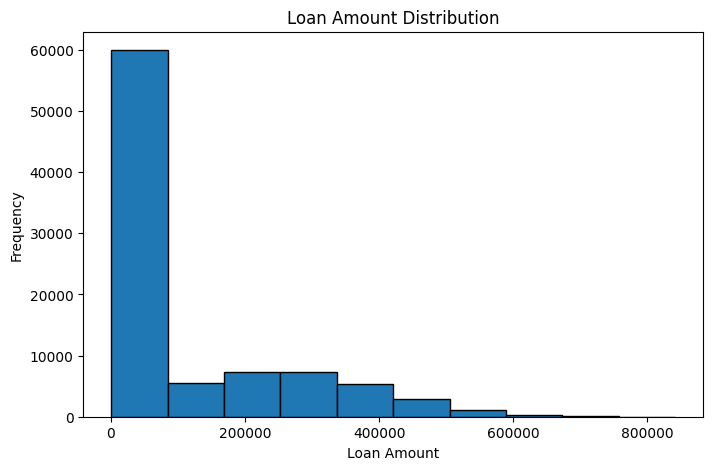

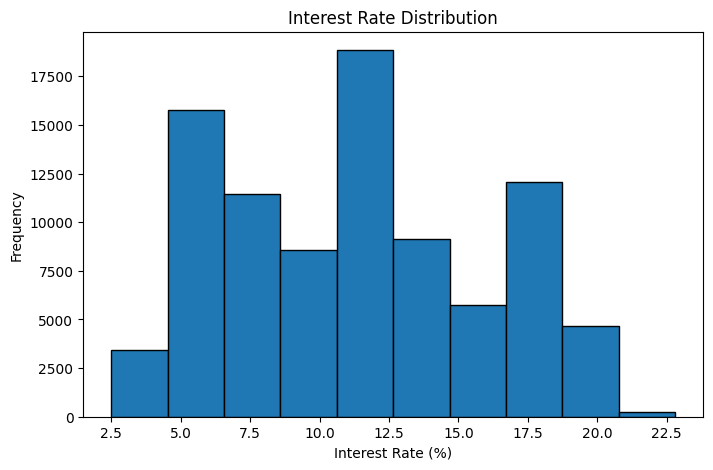


=== AVERAGE INTEREST RATE BY LOAN TYPE ===
loan_type
cc             17.675613
credit card    17.682561
creditcard     17.672052
home loan       6.191845
mortgage        6.186905
personal       11.749321
Name: interest_rate, dtype: float64


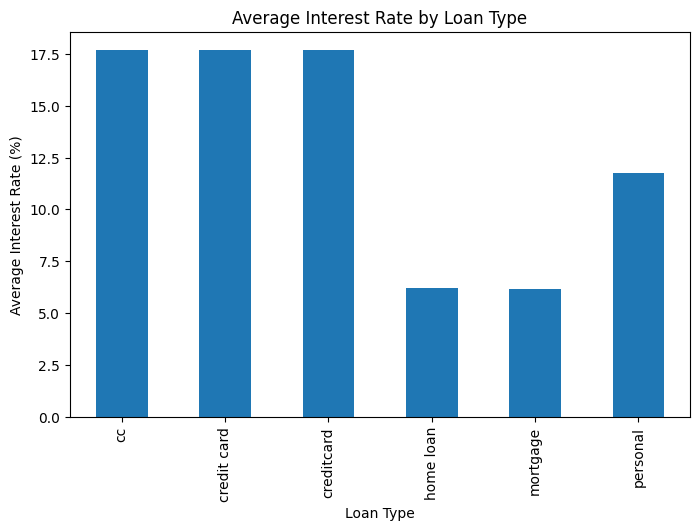

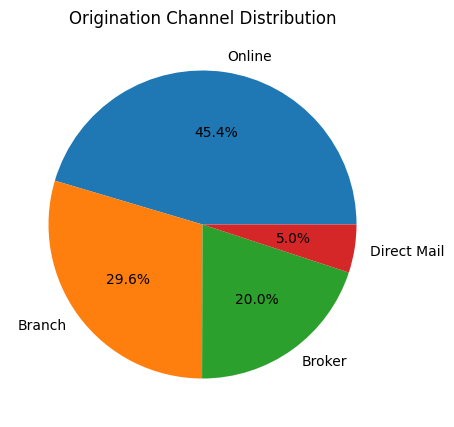

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. FAYLNI O'QISH
data = pd.read_excel("loan_details.xlsx")

# 2. CLEANING – TOZALASH

# loan_amount maydonidagi $ va vergullarni olib tashlash
data["loan_amount"] = (
    data["loan_amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# loan_type ni normalizatsiya qilish (masalan: PERSONAL, Personal Loan → personal)
data["loan_type"] = (
    data["loan_type"]
    .astype(str)
    .str.lower()
    .str.replace("personal loan", "personal")
)

# 3. DESCRIPTIVE STATISTICS
print("\n=== BASIC STATISTICS ===")
print(data.describe(include="all"))

# Unique counts
print("\n=== UNIQUE VALUE COUNTS ===")
for col in ["loan_type", "loan_purpose", "origination_channel"]:
    print(f"\n{col}:")
    print(data[col].value_counts())

# 4. LOAN AMOUNT DISTRIBUTION CHART
plt.figure(figsize=(8,5))
plt.hist(data["loan_amount"], edgecolor="black")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.title("Loan Amount Distribution")
plt.show()

# 5. INTEREST RATE DISTRIBUTION
plt.figure(figsize=(8,5))
plt.hist(data["interest_rate"], edgecolor="black")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Frequency")
plt.title("Interest Rate Distribution")
plt.show()

# 6. LOAN TYPE BO'YICHA O'RTACHA FOIZ
avg_interest = data.groupby("loan_type")["interest_rate"].mean()
print("\n=== AVERAGE INTEREST RATE BY LOAN TYPE ===")
print(avg_interest)

plt.figure(figsize=(8,5))
avg_interest.plot(kind="bar")
plt.title("Average Interest Rate by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Average Interest Rate (%)")
plt.show()

# 7. ORIGINATION CHANNEL COUNT
plt.figure(figsize=(8,5))
data["origination_channel"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Origination Channel Distribution")
plt.ylabel("")
plt.show()


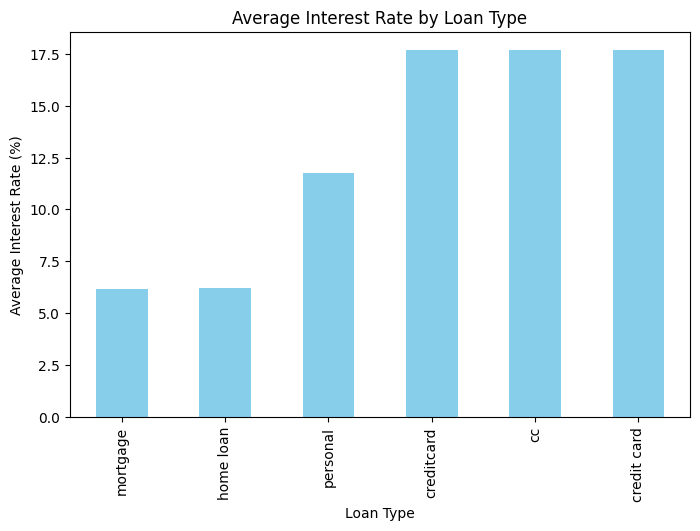

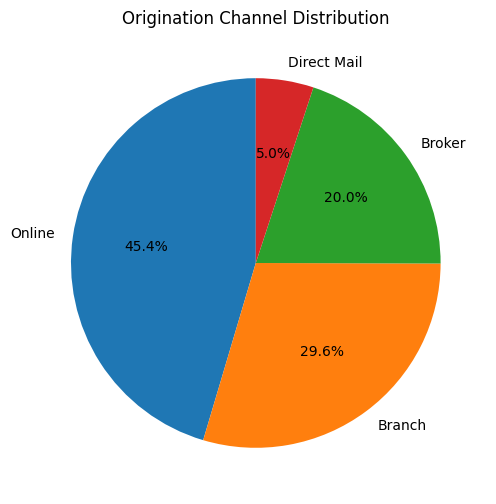

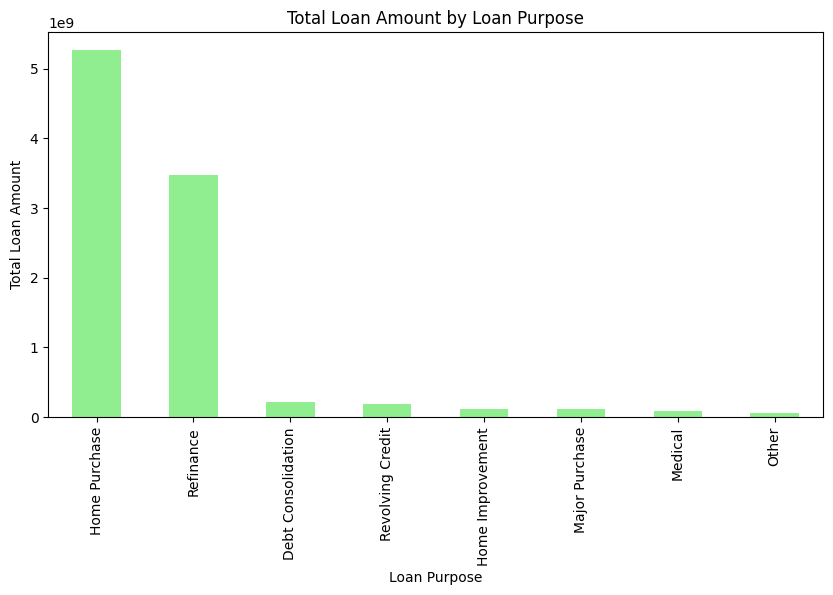

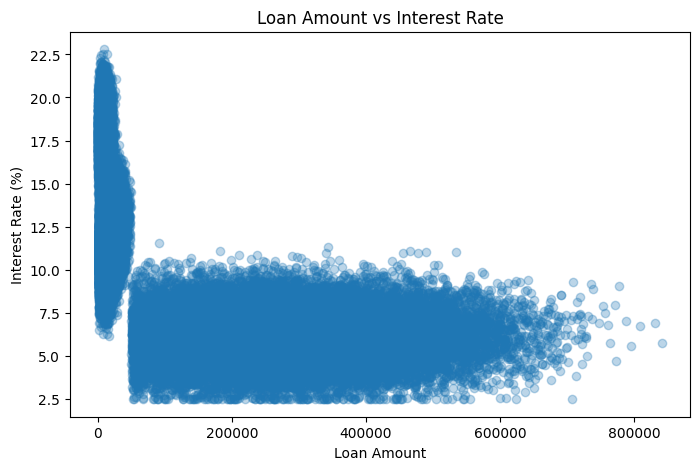

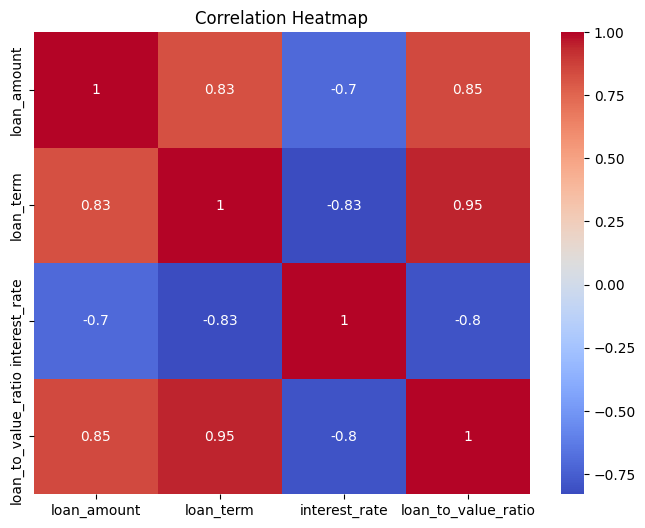

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Excel faylni o'qish
data = pd.read_excel("loan_details.xlsx")

# 2. Tozalash
data["loan_amount"] = (
    data["loan_amount"].astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

data["loan_type"] = (
    data["loan_type"].astype(str)
    .str.lower()
    .str.replace("personal loan", "personal")
)

# ===============================
# 3. Loan Type bo'yicha o'rtacha foiz
# ===============================
avg_interest = data.groupby("loan_type")["interest_rate"].mean().sort_values()
plt.figure(figsize=(8,5))
avg_interest.plot(kind="bar", color="skyblue")
plt.title("Average Interest Rate by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Average Interest Rate (%)")
plt.show()

# ===============================
# 4. Origination Channel taqsimoti (pie chart)
# ===============================
plt.figure(figsize=(6,6))
data["origination_channel"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Origination Channel Distribution")
plt.ylabel("")
plt.show()

# ===============================
# 5. Loan Purpose bo'yicha kredit miqdori
# ===============================
loan_purpose_sum = data.groupby("loan_purpose")["loan_amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
loan_purpose_sum.plot(kind="bar", color="lightgreen")
plt.title("Total Loan Amount by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Total Loan Amount")
plt.show()

# ===============================
# 6. Loan Amount va Interest Rate Scatter Plot
# ===============================
plt.figure(figsize=(8,5))
plt.scatter(data["loan_amount"], data["interest_rate"], alpha=0.3)
plt.title("Loan Amount vs Interest Rate")
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate (%)")
plt.show()

# ===============================
# 7. Correlation Heatmap
# ===============================
numeric_cols = ["loan_amount","loan_term","interest_rate","loan_to_value_ratio"]
plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [10]:
import pandas as pd

# 1. Excel faylni o'qish
data = pd.read_excel("loan_details.xlsx")

# 2. loan_amount ustunini numeric formatga o'tkazish
# Agar $ yoki vergul bo'lsa olib tashlaymiz
data["loan_amount"] = (
    data["loan_amount"].astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

# 3. Outlier detection funksiyasi (IQR usuli)
def detect_outliers(df, cols):
    for col in cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in DataFrame. Skipping...")
            continue
        
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"Column '{col}' is not numeric. Skipping...")
            continue
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nColumn: {col}")
        print(f" - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
        print(f" - Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        print(f" - Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f" - Outlier values (sample up to 10): {outliers.values[:10]}")
        else:
            print(" - No outliers detected.")

# 4. Numeric ustunlar ro'yxati
numeric_columns = ["loan_amount", "loan_term", "interest_rate", "loan_to_value_ratio"]

# 5. Funksiyani chaqirish
detect_outliers(data, numeric_columns)



Column: loan_amount
 - Q1: 9800.0, Q3: 192800.0, IQR: 183000.0
 - Lower Bound: -264700.0, Upper Bound: 467300.0
 - Outliers count: 2582
 - Outlier values (sample up to 10): [638300. 499100. 507500. 543200. 522900. 477300. 477400. 494100. 564500.
 491800.]

Column: loan_term
 - Q1: 12.0, Q3: 360.0, IQR: 348.0
 - Lower Bound: -510.0, Upper Bound: 882.0
 - Outliers count: 0
 - No outliers detected.

Column: interest_rate
 - Q1: 6.96, Q3: 14.82, IQR: 7.86
 - Lower Bound: -4.830000000000001, Upper Bound: 26.61
 - Outliers count: 0
 - No outliers detected.

Column: loan_to_value_ratio
 - Q1: 0.0, Q3: 0.725, IQR: 0.725
 - Lower Bound: -1.0875, Upper Bound: 1.8125
 - Outliers count: 0
 - No outliers detected.


In [11]:
import pandas as pd
import numpy as np

# 1. Excel faylni o'qish
data = pd.read_excel("loan_details.xlsx")

# 2. loan_amount ustunini numeric formatga o'tkazish
data["loan_amount"] = (
    data["loan_amount"].astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

# 3. MAD asosida outlier aniqlash funksiyasi
def mad_based_outlier(series, threshold=3.5):
    """
    Modified Z-score orqali outlierlarni aniqlash
    """
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return [], median, mad  # MAD 0 bo'lsa hisoblash mumkin emas
    modified_z_scores = 0.6745 * (series - median) / mad
    outliers = series[np.abs(modified_z_scores) > threshold]
    return outliers, median, mad

# 4. Har bir ustunni tekshirish va hisobot
for col in data.columns:
    if np.issubdtype(data[col].dtype, np.number):  # raqamli ustunlar
        outliers, median, mad = mad_based_outlier(data[col])
        print(f"Column: {col}")
        print(f" - Median: {median}, MAD: {mad}")
        print(f" - Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f" - Outlier values (sample up to 10): {outliers.values[:10]}\n")
        else:
            print(f" - No outliers detected.\n")
    else:  # kategorik ustunlar uchun
        print(f"Column: {col} → MAD is 0, cannot compute Modified Z-score reliably.\n")


Column: customer_id
 - Median: 54999.0, MAD: 22500.0
 - Outliers count: 0
 - No outliers detected.

Column: loan_type → MAD is 0, cannot compute Modified Z-score reliably.

Column: loan_amount
 - Median: 19200.0, MAD: 12800.0
 - Outliers count: 29944
 - Outlier values (sample up to 10): [114000.  99100. 360600. 221900. 110500. 411000. 220900. 119900. 453800.
 638300.]

Column: loan_term
 - Median: 48.0, MAD: 48.0
 - Outliers count: 26662
 - Outlier values (sample up to 10): [360 360 360 360 360 360 360 360 360 360]

Column: interest_rate
 - Median: 11.29, MAD: 4.169999999999999
 - Outliers count: 0
 - No outliers detected.

Column: loan_purpose → MAD is 0, cannot compute Modified Z-score reliably.

Column: loan_to_value_ratio
 - Median: 0.0, MAD: 0.0
 - Outliers count: 0
 - No outliers detected.

Column: origination_channel → MAD is 0, cannot compute Modified Z-score reliably.

Column: loan_officer_id
 - Median: 1048.0, MAD: 32.0
 - Outliers count: 0
 - No outliers detected.

Column: m

=== Numeric columns outlier analysis ===

Column: customer_id
 - Median: 54999.0, MAD: 22500.0
 - Outliers count: 0
 - No outliers detected.

Column: loan_amount
 - Median: 19200.0, MAD: 12800.0
 - Outliers count: 29944
 - Outlier values (sample up to 10): [114000.  99100. 360600. 221900. 110500. 411000. 220900. 119900. 453800.
 638300.]

Column: loan_term
 - Median: 48.0, MAD: 48.0
 - Outliers count: 26662
 - Outlier values (sample up to 10): [360 360 360 360 360 360 360 360 360 360]

Column: interest_rate
 - Median: 11.29, MAD: 4.169999999999999
 - Outliers count: 0
 - No outliers detected.

Column: loan_to_value_ratio
 - Median: 0.0, MAD: 0.0
 - Outliers count: 0
 - No outliers detected.

Column: loan_officer_id
 - Median: 1048.0, MAD: 32.0
 - Outliers count: 0
 - No outliers detected.

=== Categorical columns rare value analysis ===

Column: loan_type
 - No rare values detected.

Column: loan_purpose
 - No rare values detected.

Column: origination_channel
 - No rare values detecte

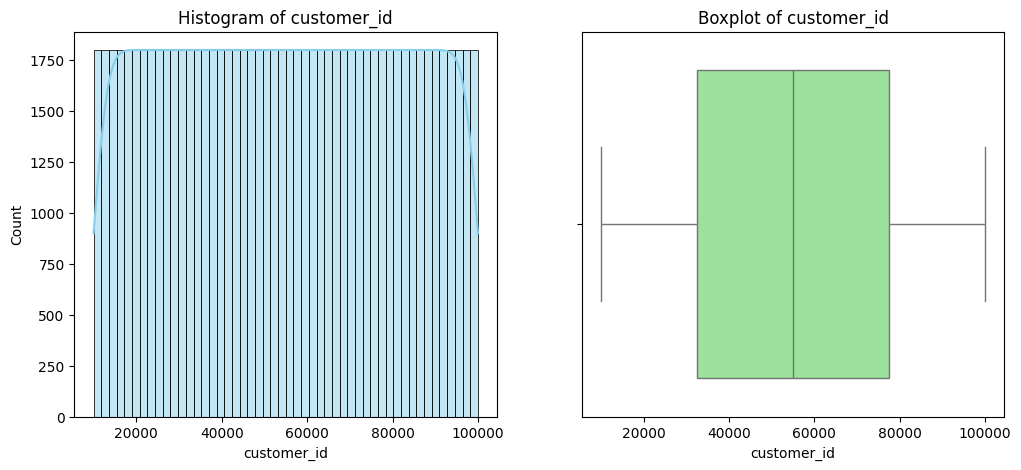

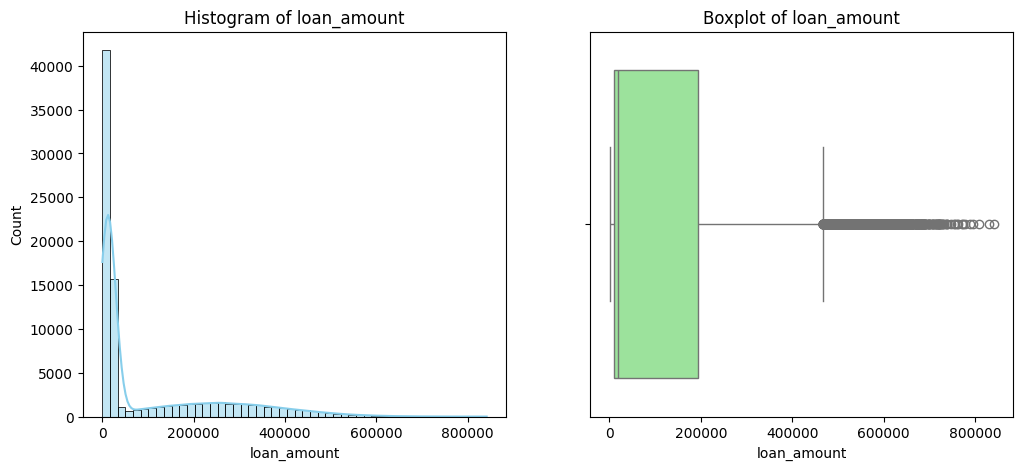

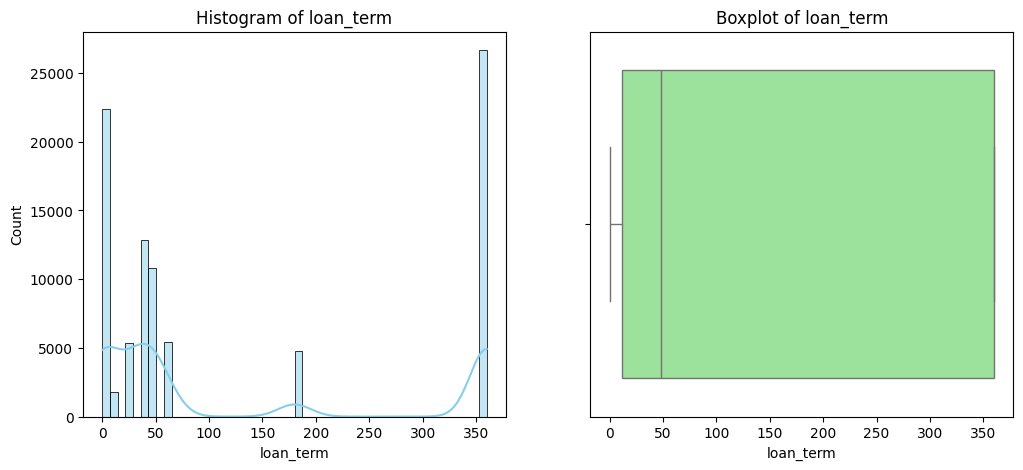

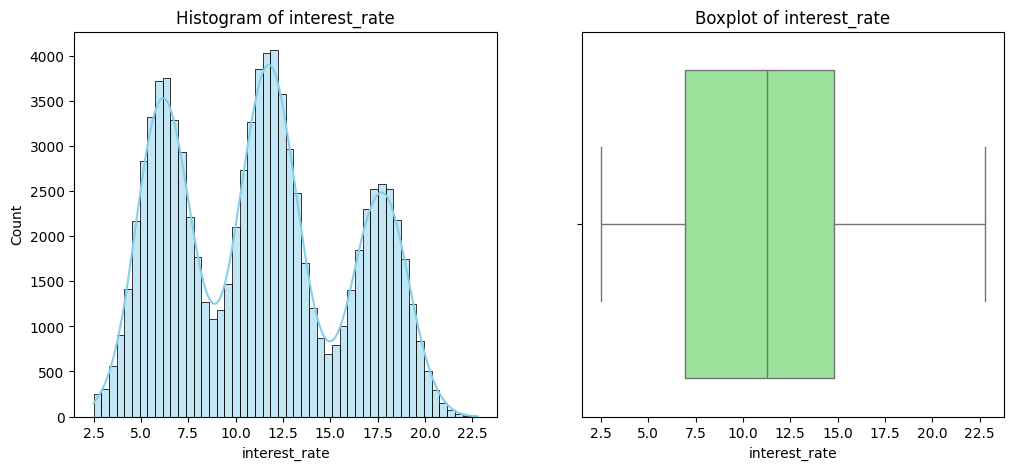

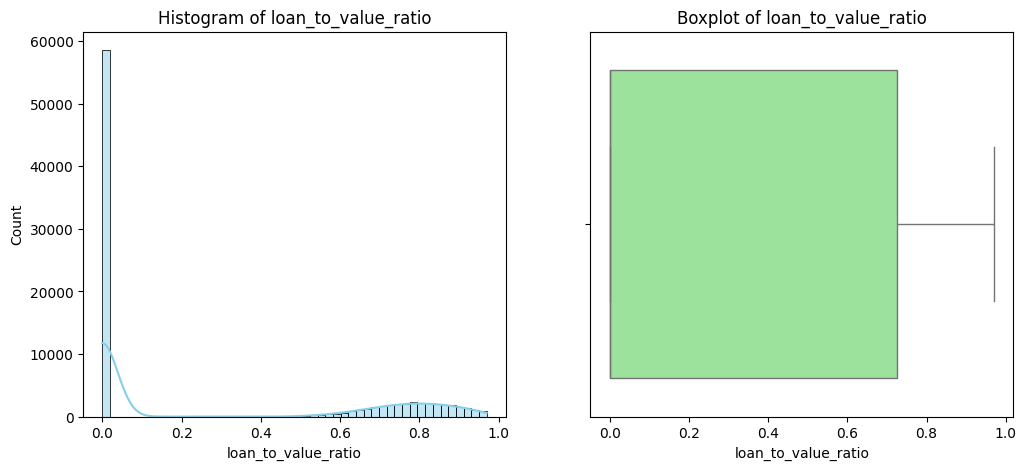

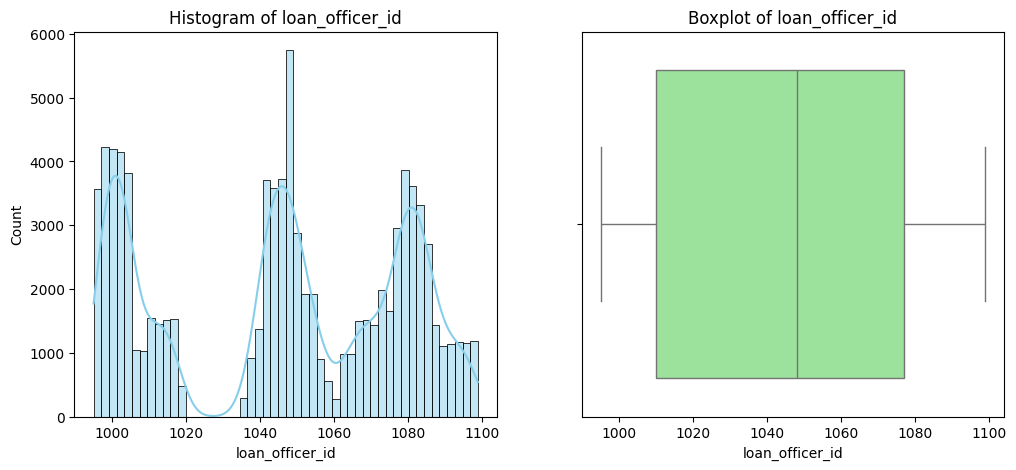

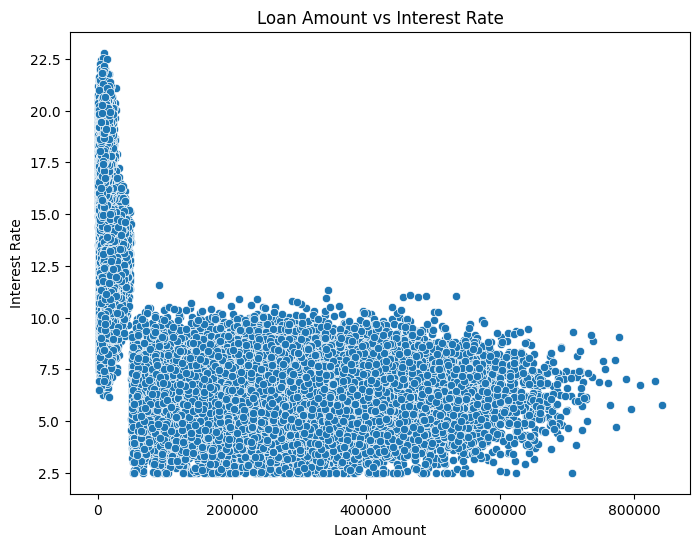

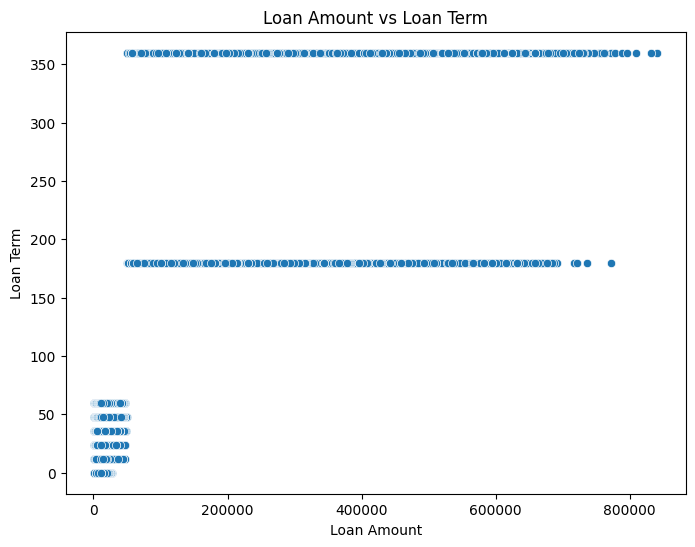

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Excel faylni o'qish
data = pd.read_excel("loan_details.xlsx")

# 2. loan_amount ustunini numeric formatga o'tkazish
data["loan_amount"] = (
    data["loan_amount"].astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

# 3. MAD bo'yicha outlier aniqlash funksiyasi
def mad_based_outlier(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return [], median, mad
    modified_z_scores = 0.6745 * (series - median) / mad
    outliers = series[np.abs(modified_z_scores) > threshold]
    return outliers, median, mad

# 4. Numeric va kategorik ustunlar ajratish
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

print("=== Numeric columns outlier analysis ===\n")
for col in numeric_cols:
    outliers, median, mad = mad_based_outlier(data[col])
    print(f"Column: {col}")
    print(f" - Median: {median}, MAD: {mad}")
    print(f" - Outliers count: {len(outliers)}")
    if len(outliers) > 0:
        print(f" - Outlier values (sample up to 10): {outliers.values[:10]}\n")
    else:
        print(f" - No outliers detected.\n")

print("=== Categorical columns rare value analysis ===\n")
for col in categorical_cols:
    counts = data[col].value_counts()
    rare_values = counts[counts < 0.01 * len(data)]  # 1% dan kam uchraydigan
    print(f"Column: {col}")
    if len(rare_values) > 0:
        print(f" - Rare values (less than 1% of data):\n{rare_values}\n")
    else:
        print(" - No rare values detected.\n")

# 5. Vizualizatsiya

# Histogram va Boxplot numeric ustunlar uchun
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(data[col], bins=50, kde=True, color="skyblue")
    plt.title(f"Histogram of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
    
    plt.show()

# Scatter plot numeric ustunlar o'rtasida
if "loan_amount" in numeric_cols and "interest_rate" in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data["loan_amount"], y=data["interest_rate"])
    plt.title("Loan Amount vs Interest Rate")
    plt.xlabel("Loan Amount")
    plt.ylabel("Interest Rate")
    plt.show()

if "loan_amount" in numeric_cols and "loan_term" in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data["loan_amount"], y=data["loan_term"])
    plt.title("Loan Amount vs Loan Term")
    plt.xlabel("Loan Amount")
    plt.ylabel("Loan Term")
    plt.show()
